正在计算大盘择时信号 (MA60)...
正在读取并过滤主板数据...
开始执行【均线择时 + 小市值低估值】轮动模拟...

✅ 择时策略交易明细已成功导出至: F:\self_quant\data\data\择时轮动策略交易明细.xlsx
💰 初始本金: 50,000.00 元
💰 择时策略最终总资产: 117,318.01 元
📈 策略总收益率: 134.64%


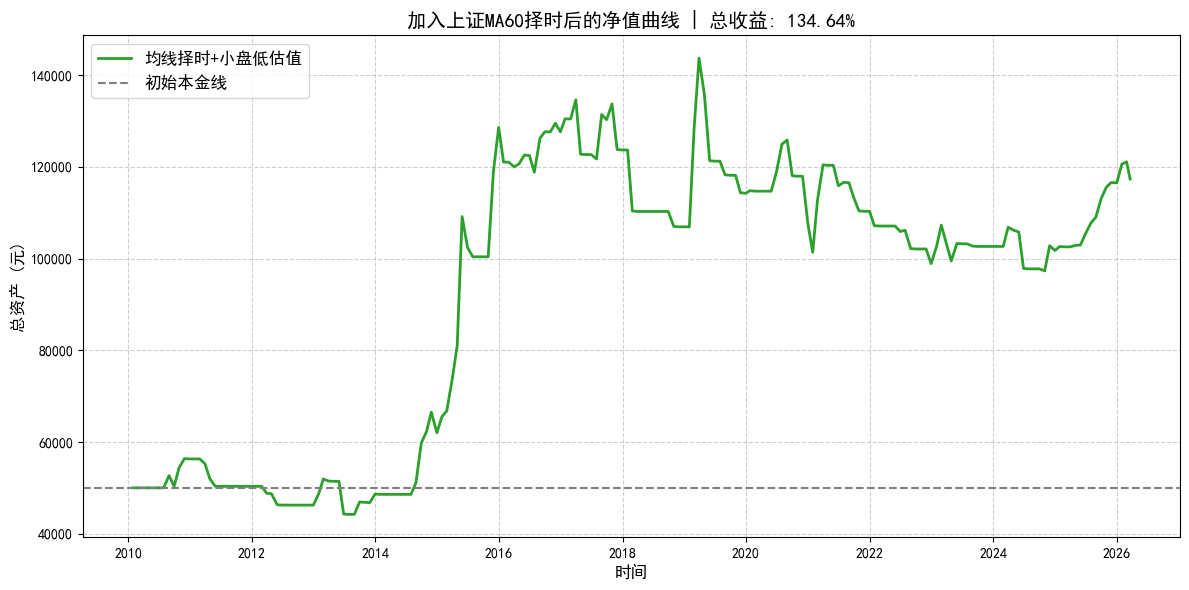

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与路径
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
INDEX_PATH = r"F:\self_quant\data\data\指数\上证指数_2010-2026.csv"  # 择时风向标
OUTPUT_EXCEL = r"F:\self_quant\data\data\择时轮动策略交易明细.xlsx"

INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10
MA_WINDOW = 60          # 择时均线周期：60日线 (季线)

# ==========================================
# 第二步：读取并处理【指数择时数据】
# ==========================================
print("正在计算大盘择时信号 (MA60)...")
try:
    index_df = pd.read_csv(INDEX_PATH, encoding='gbk')
except:
    index_df = pd.read_csv(INDEX_PATH, encoding='utf-8')

# 兼容列名：防范炒股软件导出的列名是中文 "日期" 和 "收盘价"
index_df.rename(columns={'日期': 'date', '收盘价': 'close'}, inplace=True)

index_df['date'] = pd.to_datetime(index_df['date'])
index_df.sort_values('date', inplace=True)
index_df.set_index('date', inplace=True)

# 计算 60 日均线
index_df['MA60'] = index_df['close'].rolling(window=MA_WINDOW).mean()
# 判断是否为牛市 (收盘价站上60日均线)
index_df['Bull_Market'] = index_df['close'] >= index_df['MA60']

# 将牛熊信号转为字典，方便按日期快速查询
index_signal = index_df['Bull_Market'].to_dict()

# ==========================================
# 第三步：读取全市场股票数据
# ==========================================
print("正在读取并过滤主板数据...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤主板
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

df.sort_values(by=['date', 'code'], inplace=True)
df['year_month'] = df['date'].dt.to_period('M')
trade_dates = df.groupby('year_month')['date'].max().sort_values().tolist()

# ==========================================
# 第四步：定义交易费率与账户类
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_date, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

print("开始执行【均线择时 + 小市值低估值】轮动模拟...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    current_prices = daily_data['close'].to_dict()

    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    # 获取当天的牛熊信号（若周末/节假日导致日期对不上，往前取最近一个交易日的信号）
    closest_date = index_df.index[index_df.index <= date].max()
    if pd.isna(closest_date):
        is_bull_market = True # 数据不足时默认允许多头
    else:
        is_bull_market = index_signal.get(closest_date, True)

    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 选股逻辑 (结合择时) ----------------
    target_codes = []

    # 核心：只有在大盘处于牛市/震荡市 (指数 > MA60) 时，才生成买入名单
    if is_bull_market:
        valid_pool = daily_data[
            (daily_data['tradestatus'] == 1) &
            (daily_data['isST'] == 0) &
            (daily_data['peTTM'] > 0)
        ].copy()

        if len(valid_pool) >= 50:
            smallest_50 = valid_pool.sort_values(by='流通市值', ascending=True).head(50).copy()
            smallest_50['pe_rank'] = smallest_50['peTTM'].rank()
            smallest_50['pb_rank'] = smallest_50['pbMRQ'].rank()
            smallest_50['score'] = smallest_50['pe_rank'] + smallest_50['pb_rank']
            target_codes = smallest_50.sort_values(by='score').head(TARGET_STOCK_NUM).index.tolist()
    else:
        # 熊市信号触发！目标池设为空，准备清仓
        target_codes = []

    # ---------------- 卖出逻辑 ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            if is_trading and pct_chg > -9.8:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                # 记录是常规调仓还是熊市清仓
                action_memo = '熊市空仓避险' if not is_bull_market else '常规换仓卖出'
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '大盘状态': '牛市/震荡' if is_bull_market else '熊市(指数<MA60)',
                    '备注': action_memo
                })
            elif pct_chg <= -9.8:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '大盘状态': '牛市/震荡' if is_bull_market else '熊市(指数<MA60)',
                    '备注': f'跌幅 {pct_chg:.2f}% 封死跌停'
                })

    # ---------------- 买入逻辑 ----------------
    stocks_to_buy = [code for code in target_codes if code not in account.positions]

    # 只有目标池有股票（且大盘在 MA60 之上），才会执行买入
    if len(stocks_to_buy) > 0 and is_bull_market:
        target_cash_per_stock = account.cash / len(stocks_to_buy)

        for code in stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            is_st = st_dict.get(code, 0) == 1

            if is_trading and not is_st and pct_chg < 9.8:
                buy_price = current_prices[code]
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)

                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                            '大盘状态': '牛市/震荡',
                            '备注': '常规换仓买入'
                        })
            elif pct_chg >= 9.8:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '买入失败(涨停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '大盘状态': '牛市/震荡',
                    '备注': f'涨幅 {pct_chg:.2f}% 封死涨停'
                })

# ==========================================
# 第五步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ 择时策略交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 择时策略最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#2ca02c', linewidth=2, label='均线择时+小盘低估值')
plt.title(f'加入上证MA60择时后的净值曲线 | 总收益: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金线')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()